# Nain anorthosite ca. 1305 Ma paleomagnetic pole

## Geologic context

The Nain anorthosite (Nain Plutonic Suite) of coastal Labrador is one of the
massif-type anorthosite complexes that lie north of the Grenville Front and are
unaffected by Grenvillian metamorphism (Murthy, 1978). It comprises some
10,000 km² of anorthosite and related leuconorite-norite-troctolite, subdivided
by Wheeler (1960) into dark, pale, and buff facies. The complex was intruded over
a span of time around the Mesoproterozoic; the Kiglapait layered intrusion within
it gives a Sm-Nd age of 1305 ± 22 Ma (DePaolo, 1985), used here as the pole age,
while Rb-Sr on the host anorthosite gives ca. 1418 ± 25 Ma (Barton, 1974).

## Paleomagnetic And Rock Magnetic Data

This notebook recreates the Nain anorthosite pole at the site level from the 21
sites of Murthy (1978) — 18 dark-facies (Palungotok Island and south of Nain) and
3 pale-facies (Paul Island) sites — whose magnetite remanence was isolated by
thermal demagnetization. The collection records a magnetic reversal (a subset of
sites carry the antipodal, easterly direction), supporting a primary origin.

## Age Constraints

- Current bracket: nominal age 1328 Ma, lomagage 1320 Ma, himagage 1350 Ma.
- Proposed new bracket: nominal age 1305 Ma, lomagage 1283 Ma, himagage 1328 Ma.
- A hornblende 40Ar/39Ar age of 1328 ± 8 Ma has been obtained from the contact aureole of the Bird Lake Massif, confirming it as one of the oldest members of the Nain plutonic suite (Yu & Morse, 1993). Ryan et al., 2017 reported Nain Plutonic Suite (NPS) from the region directly west of Kingurutik Lake in north-central Labrador. Leuconoritic rocks crystallized at 1349 ± 1 Ma, contemporaneous with a granitic body at 1348 ± 1 Ma. A composite ‘dioritic’ association was intruded ca. 1342-1341 Ma, and leucogranite dykes were emplaced at 1337 ± 1 Ma. DePaolo, 1985 reported a Sm-Nd mineral isochron indicates that the crystallization age of the intrusion is 1305±22 Ma.


## References
- Paleomagnetic source: Murthy, G. S. (1978). Paleomagnetic results from the Nain anorthosite and their tectonic implications. Canadian Journal of Earth Sciences, 15(4), 516–525. https://doi.org/10.1139/e78-058

- Geochronology / age-constraint note (compilation): Yu, Y., & Morse, S. A. (1993). 40Ar/39Ar chronology of the Nain anorthosites, Canada. Canadian Journal of Earth Sciences, 30(6), 1166–1178. https://doi.org/10.1139/e93-099
- Ryan, B., Connelly, J., & James, D. (2017). U-pb geochronology of the western part of the nain plutonic suite, kingurutik lake area (NTS 14D/15). Canada: Newfoundland and Labrador Department of Natural Resources, Current Research, Geological Survey Report, 17–1.
- DEPAOLO, D. J. (1985). Isotopic Studies of Processes in Mafic Magma Chambers: I. The Kiglapait Intrusion, Labrador. Journal of Petrology, 26(4), 925–951. https://doi.org/10.1093/petrology/26.4.925


In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from `../data/1305_Nain/` (rebuilt from the audited Murthy
1978 contribution, with signed VGPs recomputed). Directions are in-situ
(intrusive rocks). The dark- and pale-facies sites are tagged in the
`description` field.

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1305_Nain/sites.txt')
study_lat, study_lon = 56.5, 298.2
print(sites_geo['dir_polarity'].value_counts())
dark = sites_geo[sites_geo['description'].str.contains('Dark', na=False)].reset_index(drop=True)
pale = sites_geo[sites_geo['description'].str.contains('Pale', na=False)].reset_index(drop=True)
print(f'\n{len(sites_geo)} sites: {len(dark)} dark facies, {len(pale)} pale facies')
sites_geo[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k',
           'dir_n_samples', 'dir_polarity', 'vgp_lat', 'vgp_lon']]

n    16
r     5
Name: dir_polarity, dtype: int64

21 sites: 18 dark facies, 3 pale facies


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,dir_polarity,vgp_lat,vgp_lon
0,1,56.44,298.40,95.6,-17.1,7.5,79.8,6,r,-10.4,28.6
1,2,56.44,298.40,94.2,-14.8,16.0,33.7,4,r,-8.6,29.1
2,3,56.44,298.40,277.5,13.7,9.1,55.1,6,n,9.9,206.0
3,4,56.44,298.40,282.2,17.6,5.7,179.0,5,n,14.2,203.2
4,5,56.44,298.40,273.7,21.3,9.6,49.3,6,n,11.2,211.5
5,6,56.44,298.40,276.0,18.6,7.8,96.8,5,n,11.3,208.7
6,7,56.44,298.40,275.2,18.6,12.4,39.2,5,n,10.8,209.4
7,8,56.50,298.26,286.2,19.6,11.8,61.3,4,n,17.3,200.3
8,9,56.50,298.26,277.8,18.6,6.9,96.9,6,n,12.3,207.1
9,10,56.50,298.26,283.2,16.2,8.5,51.0,7,n,14.2,201.8


## Combined pole and the magnetic reversal

The easterly (reversed) and westerly (normal) site directions differ by ~180°, a
positive reversal test; polarity is unified before computing the Fisher mean pole.

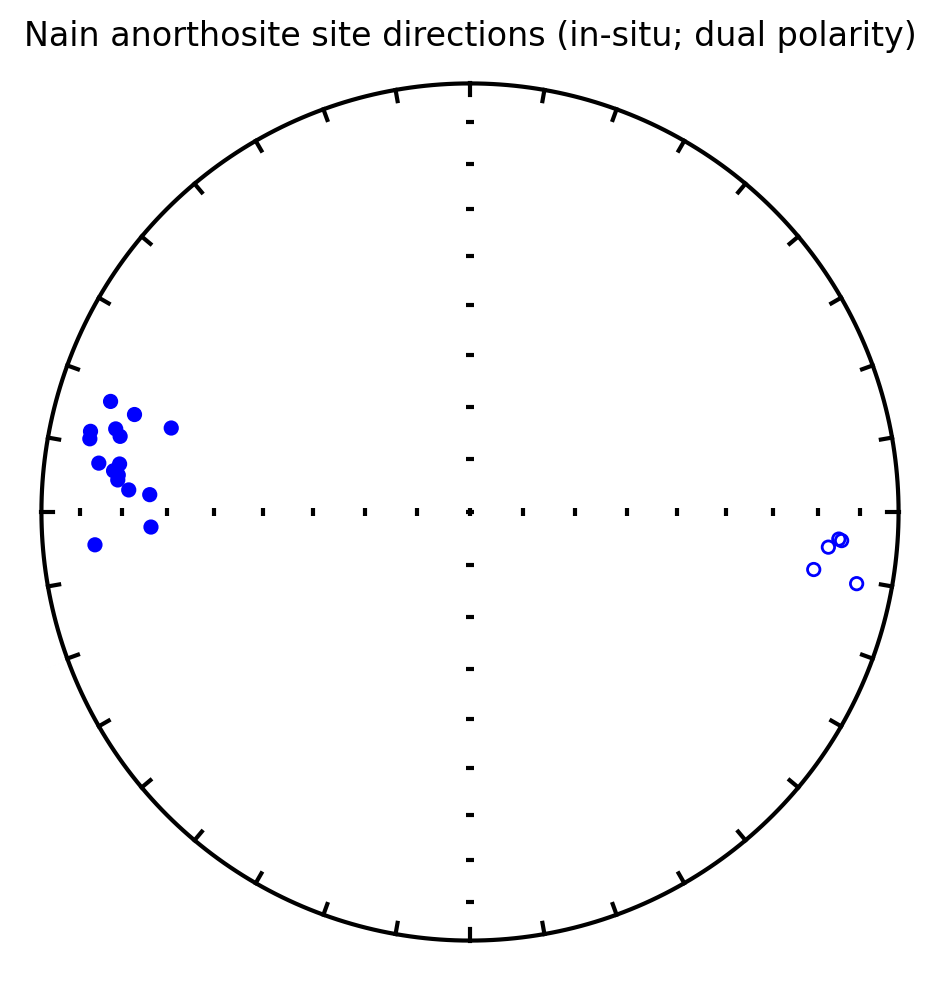

Plon: 206.8  Plat: 11.8
Number of directions in mean (n): 21
Angular radius of 95% confidence (A_95): 2.5
Precision parameter (k) estimate: 162.9

prior compilation (GPMDB 2180): 11.7 N / 206.7 E, A95 2.2, N=21
Murthy (1978) dark-facies pole: 11 N / 211 E, dp 1.5 / dm 3.0, N=18


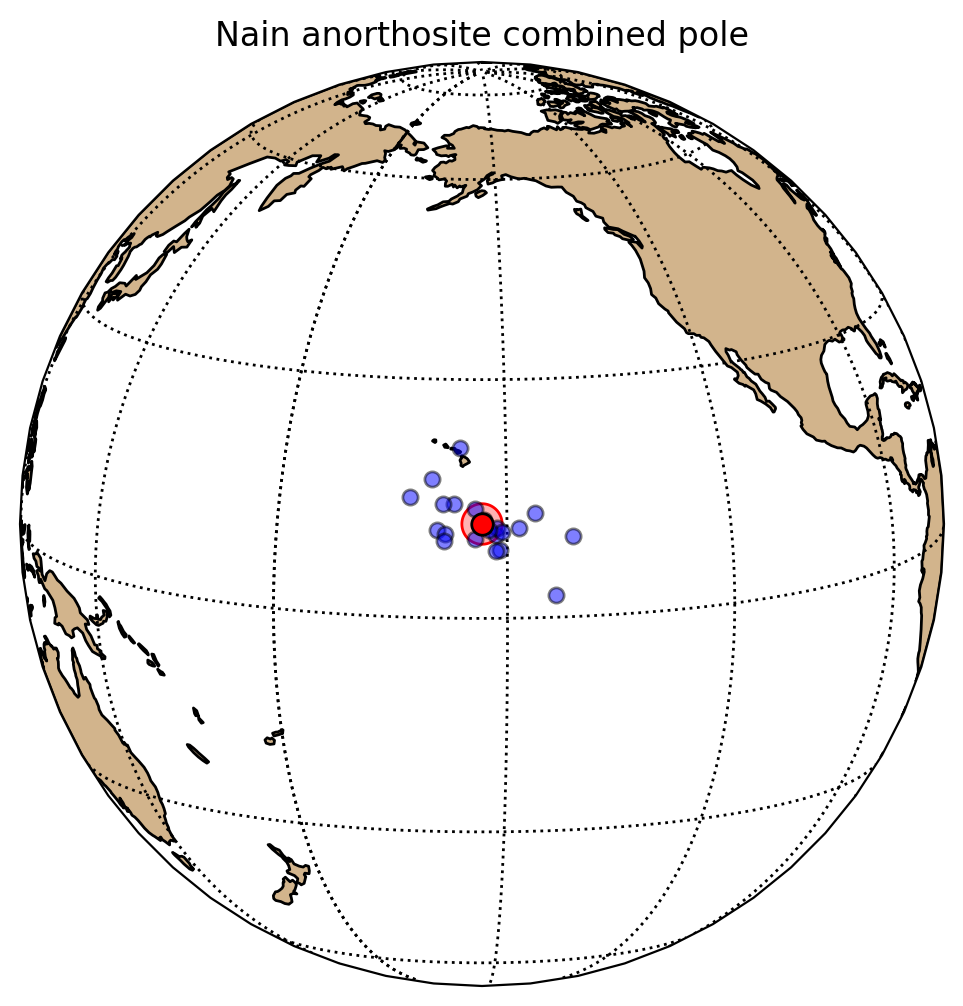

In [3]:
ipmag.plot_net()
ipmag.plot_di(sites_geo['dir_dec'].tolist(), sites_geo['dir_inc'].tolist(),
              color='blue', marker='o')
plt.title('Nain anorthosite site directions (in-situ; dual polarity)')
plt.show()

vgp_block, pole_mean = pt.compute_mean_pole(sites_geo, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nprior compilation (GPMDB 2180): 11.7 N / 206.7 E, A95 2.2, N=21')
print('Murthy (1978) dark-facies pole: 11 N / 211 E, dp 1.5 / dm 3.0, N=18')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Nain anorthosite combined pole')
plt.show()

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sites_geo, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
# dark vs pale facies poles for context
_, dark_pole = pt.compute_mean_pole(dark, unify_polarity=True)
_, pale_pole = pt.compute_mean_pole(pale, unify_polarity=True)
print(f"dark facies (N={int(dark_pole['n'])}): {dark_pole['inc']:.1f}/{dark_pole['dec']:.1f} A95 {dark_pole['alpha95']:.1f}")
print(f"pale facies (N={int(pale_pole['n'])}): {pale_pole['inc']:.1f}/{pale_pole['dec']:.1f} A95 {pale_pole['alpha95']:.1f}")

Dec: 277.8  Inc: 17.5
Number of directions in mean (n): 21
Angular radius of 95% confidence (a_95): 3.0
Precision parameter (k) estimate: 116.2
dark facies (N=18): 11.3/206.0 A95 2.4
pale facies (N=3): 14.9/212.1 A95 14.0


## Paleosecular variation and VGP-shape diagnostics

The anorthosite VGPs are tightly clustered (K ≫ 70), so the Deenen et al. (2011)
test flags possible under-sampling of paleosecular variation — consistent with
the prior compilation scoring R2 = 0 for this pole.

A_95 of 2.5 is too small for Deenen criteria of 3.6 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

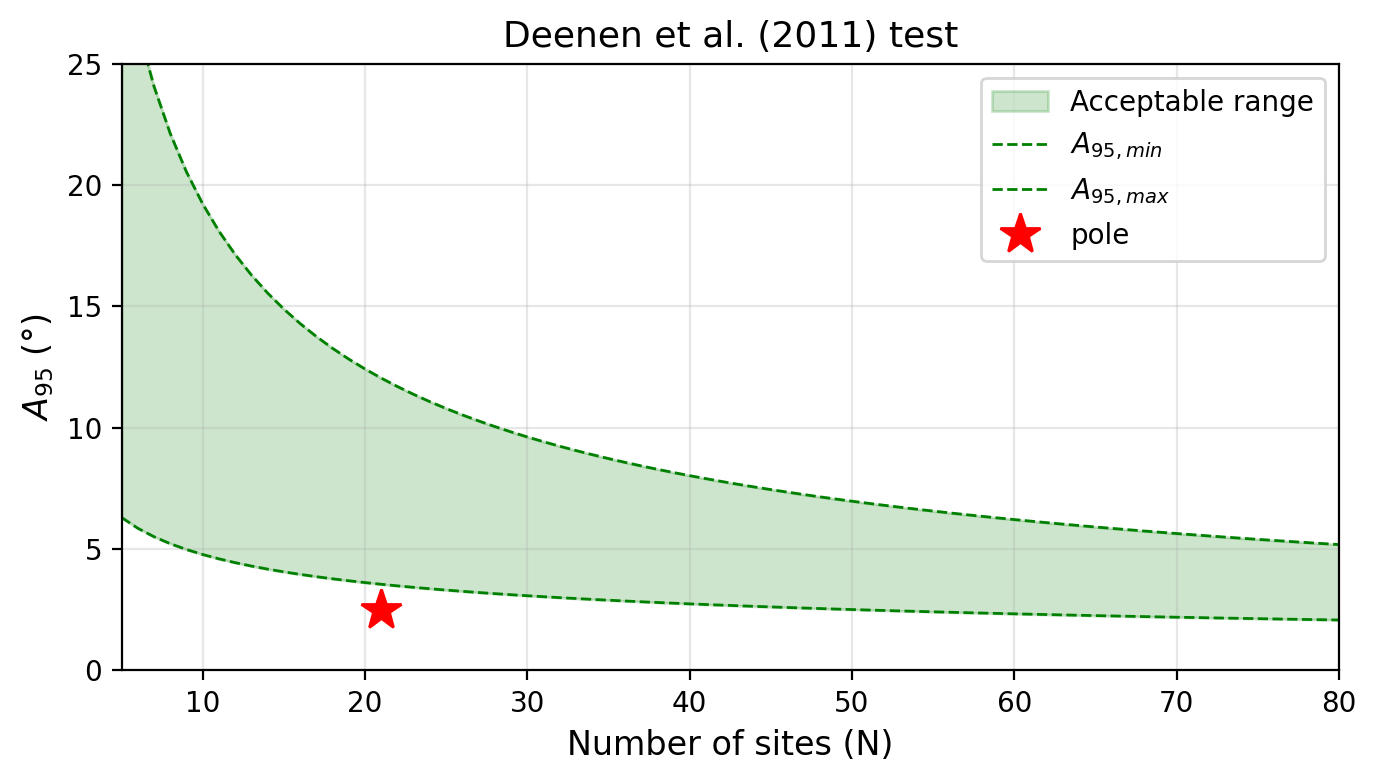

In [5]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

{'Mode': 'Mode 1',
 'Dec': 206.8217030566505,
 'Inc': 11.794660932869425,
 'N': 21,
 'Mu': 1.140888175663932,
 'Mu_critical': 1.207,
 'Me': 0.6077951216044686,
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

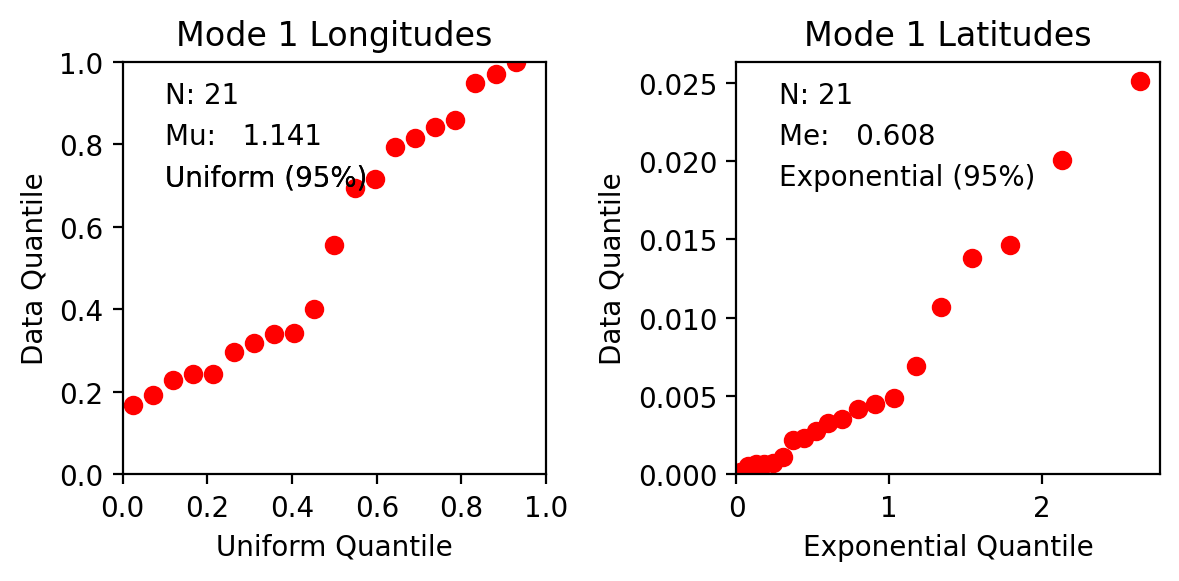

In [6]:
fishqq_result = pt.fishqq_vgps(sites_geo, unify_polarity=True)
fishqq_result

(SVEI elongation plot skipped: E below the TK03.GAD model minimum)
paleolatitude = 9.0 deg; elongation E = 1.40 (inconsistent with TK03.GAD)


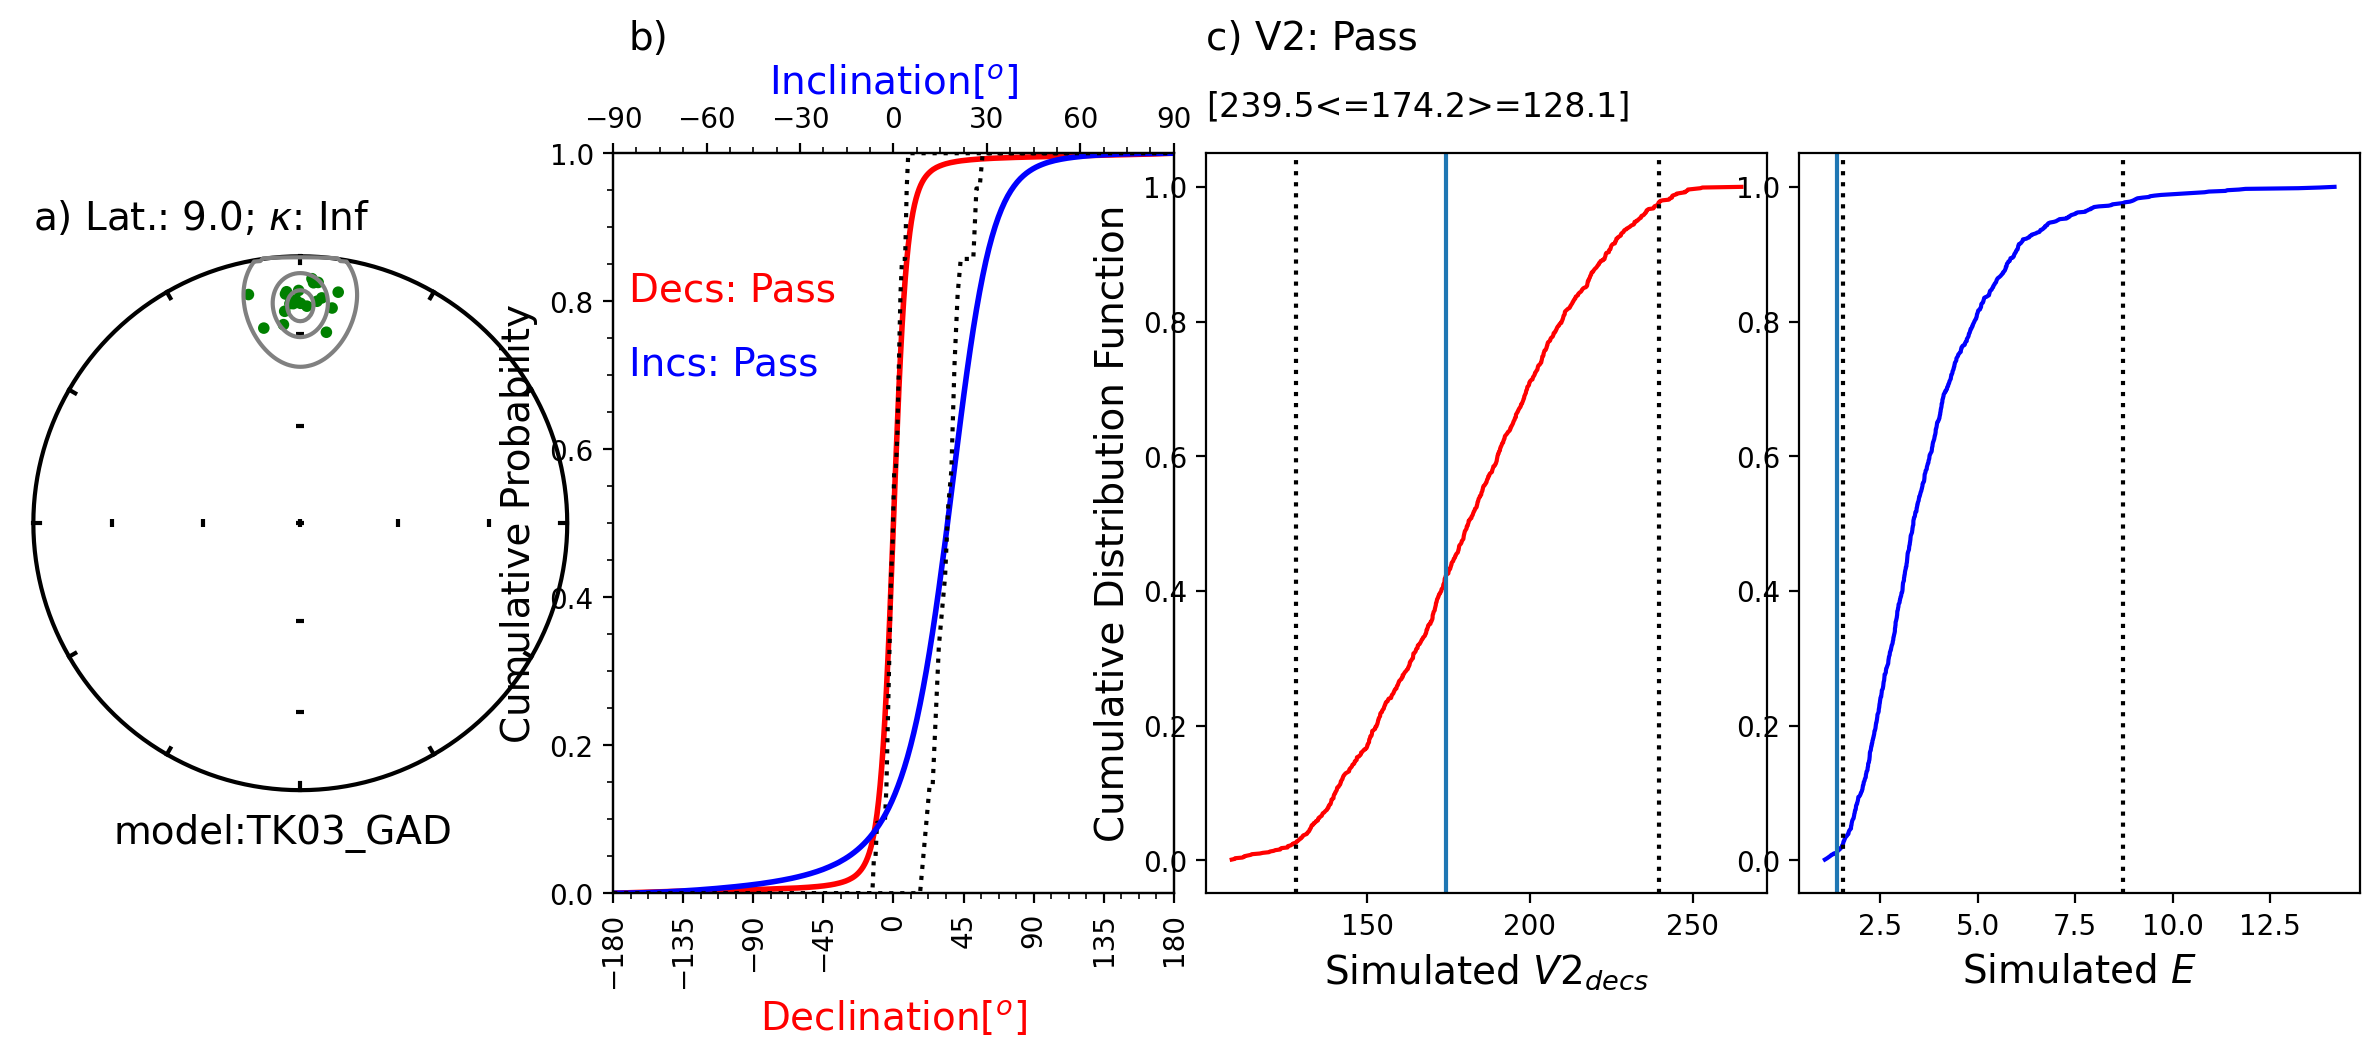

In [7]:
try:
    svei_result = pt.svei_test_vgps(sites_geo, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sites_geo, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Nain pole in the context of the Laurentia APWP

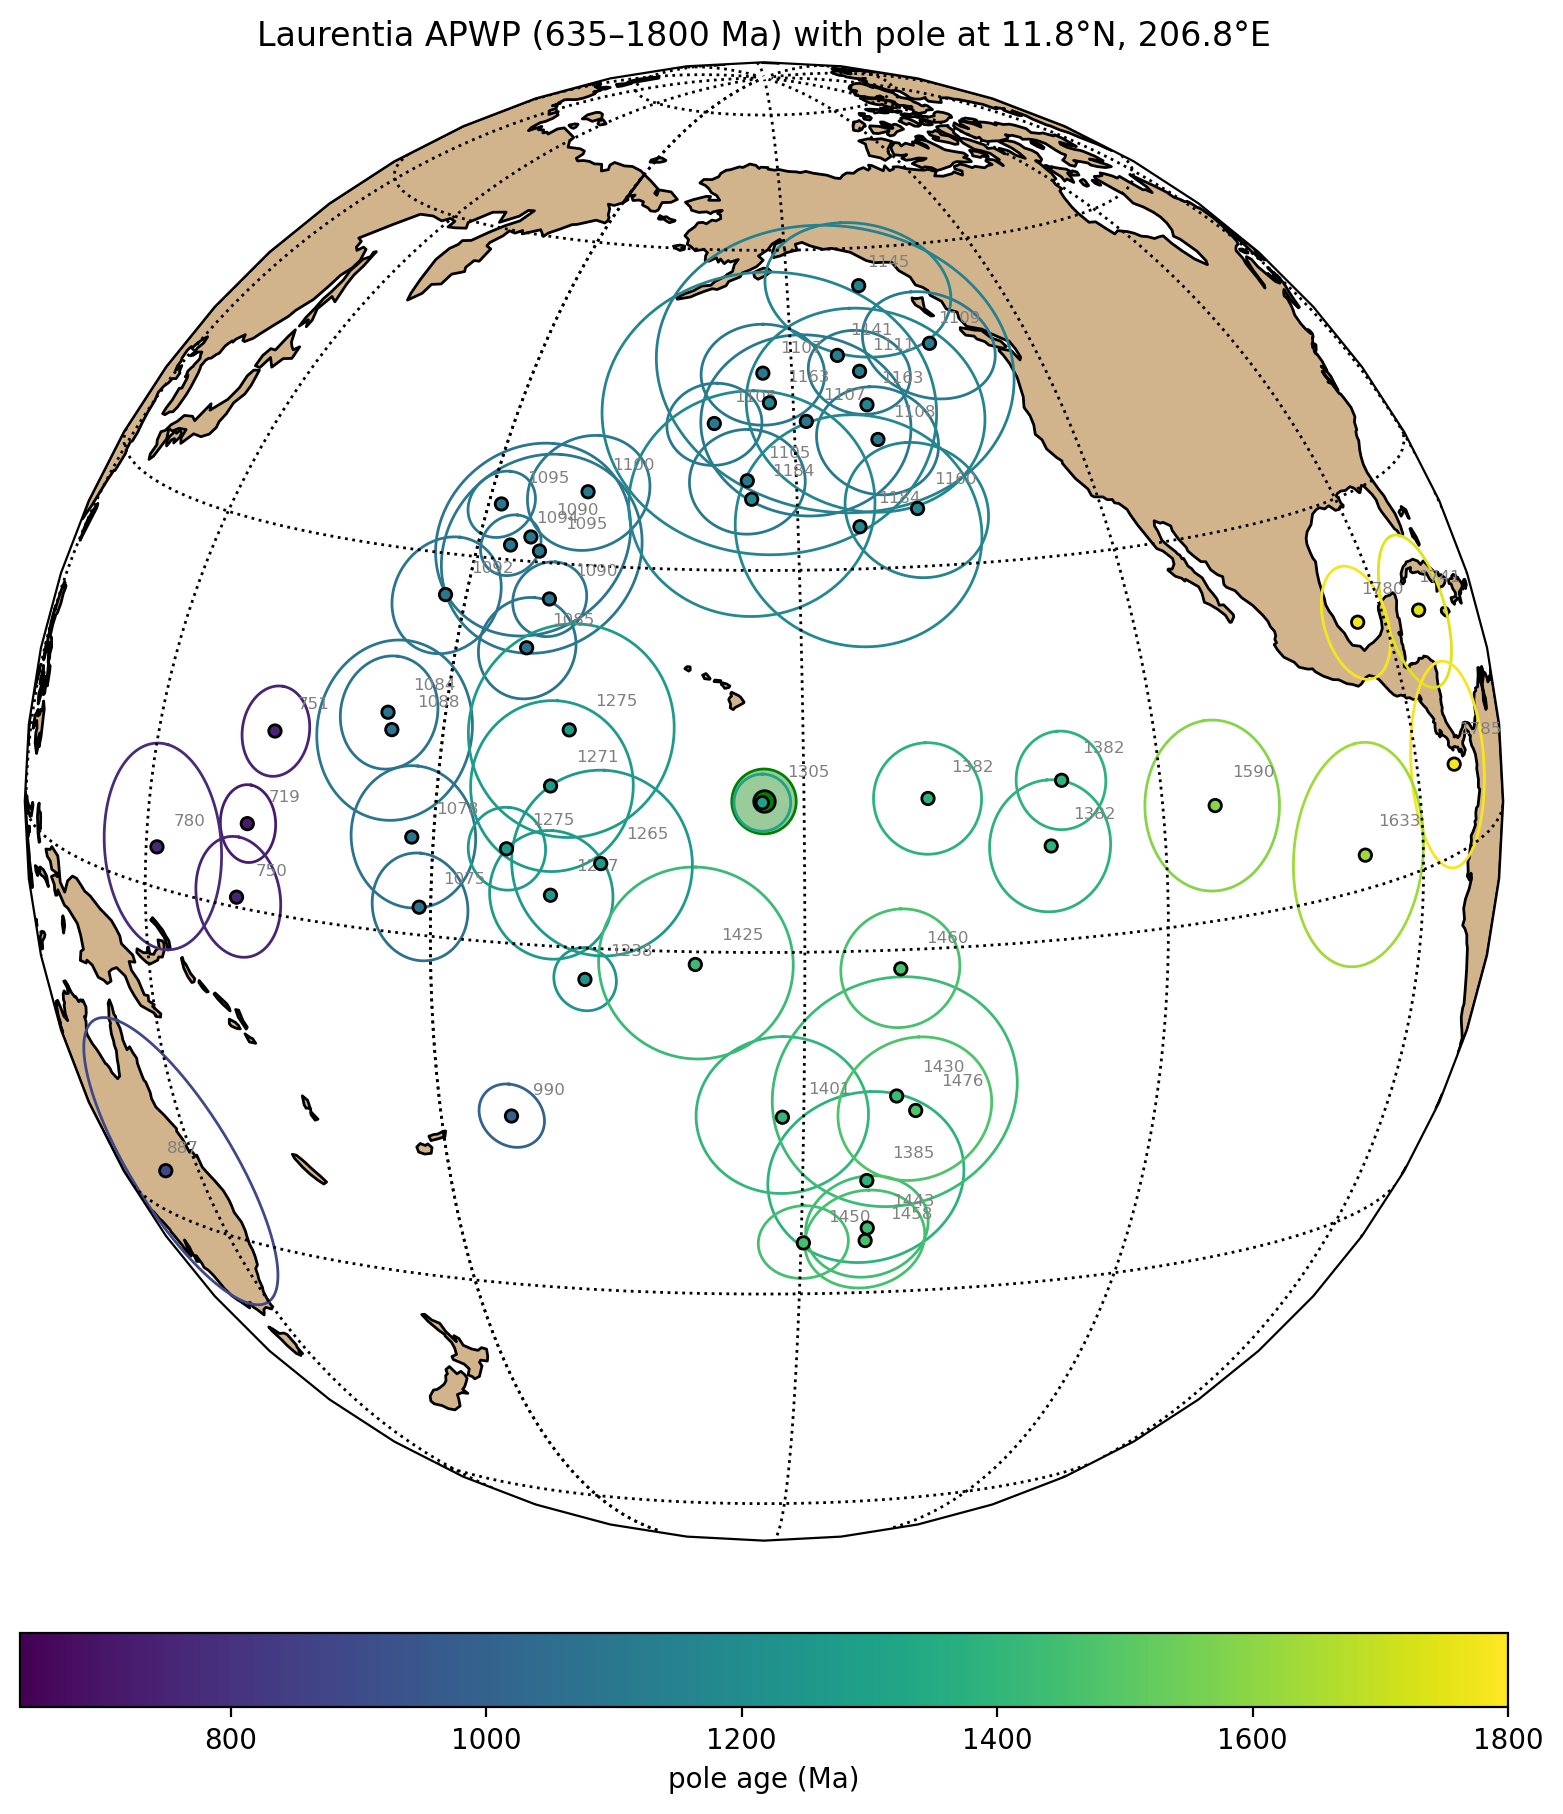

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

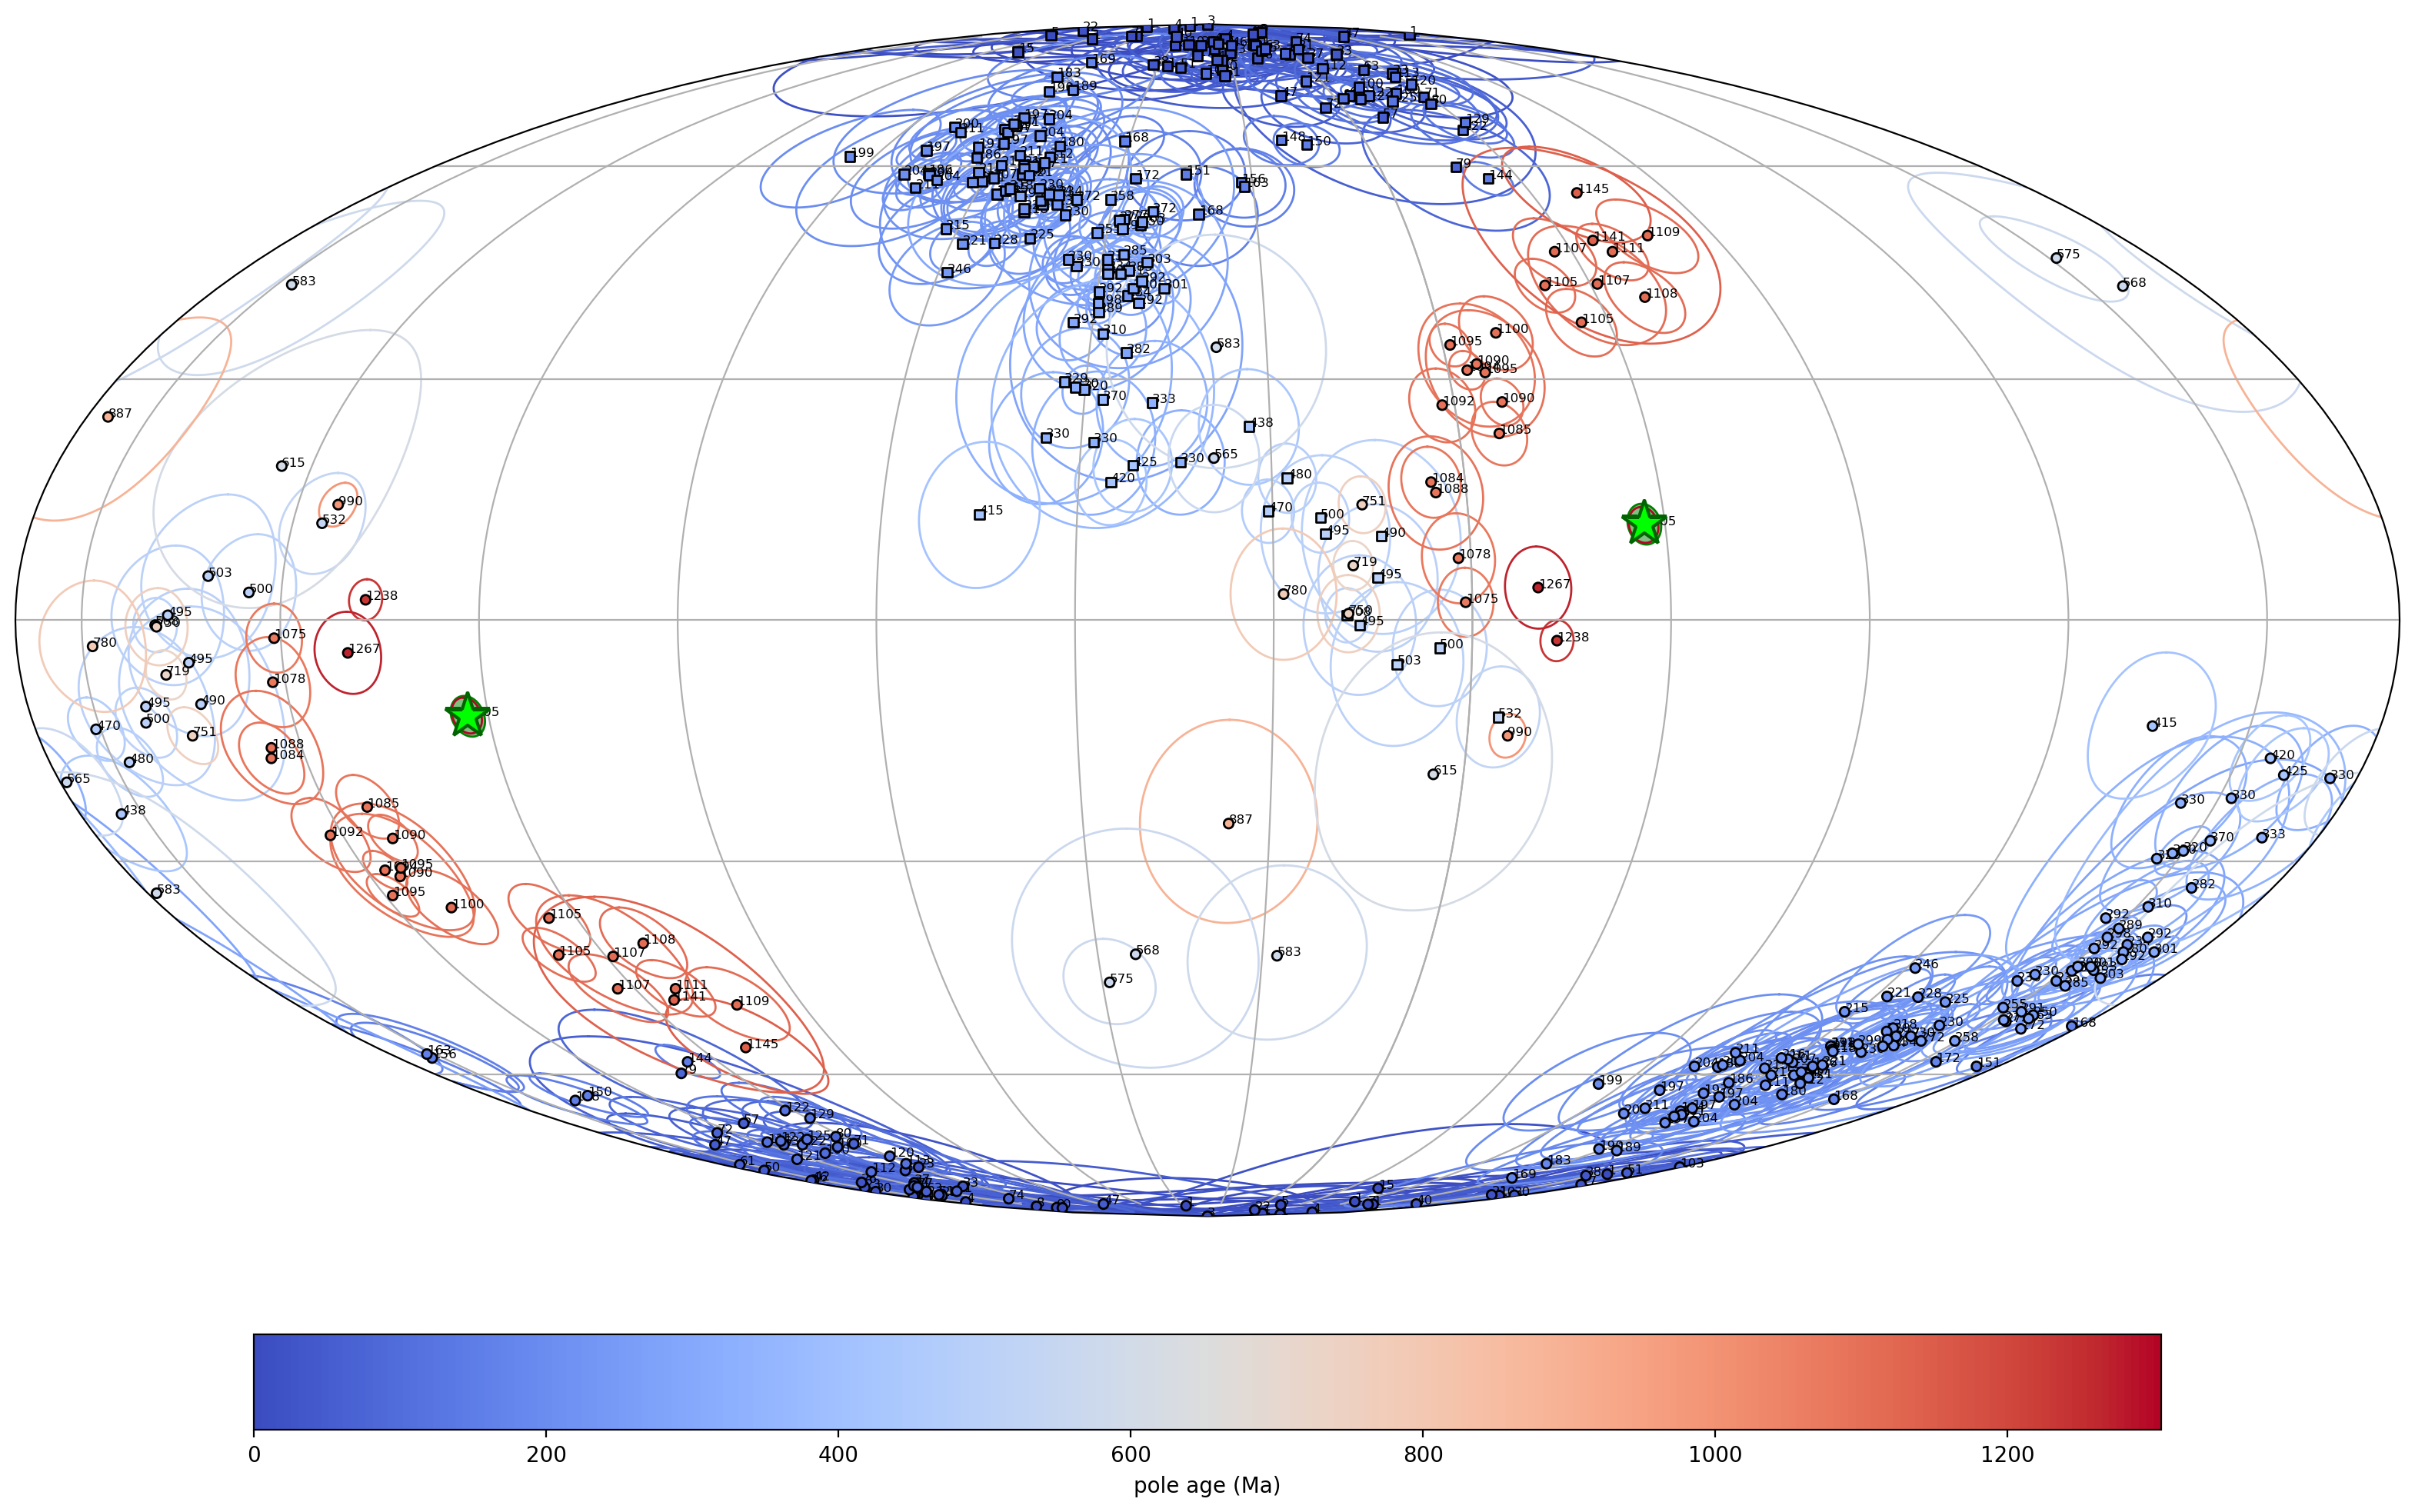

<GeoAxesSubplot:>

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Nain Anorthosite', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1305)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | Pole age 1305 ± 22 Ma (Kiglapait Sm-Nd; DePaolo, 1985); the ± 22 Ma uncertainty (and the older Rb-Sr age of the host anorthosite) exceeds ± 15 Ma. |
| 2 | Techniques and statistical analysis | **0** | Thermal demagnetization with stable end points; however the VGPs are over-concentrated (K ≈ 163 ≫ 70, A95 ≈ 2.5° below the Deenen et al. (2011) lower bound), indicating paleosecular variation is probably under-averaged. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence identified by thermomagnetic analysis and thermal demagnetization (Murthy, 1978). |
| 4 | Field tests constrain age of magnetization | **0** | No baked-contact, fold, or conglomerate test. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Nain Plutonic Suite, north of the Grenville Front and unaffected by Grenvillian metamorphism. |
| 6 | Presence of reversals | **1** | The collection records a magnetic reversal — easterly (reversed) and westerly (normal) directions ~180° apart. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **4/7** | Grade B |

## Nordic workshop summary

The Nain anorthosite pole is recreated at the site level from all 21 sites
(18 dark + 3 pale facies) of Murthy (1978), with signed VGPs recomputed
(the source contribution lacked per-site VGPs and its combined location row was
defective). The recreation (combined VGP-Fisher mean) reproduces the prior
compilation pole (11.7°N/206.7°E, GPMDB 2180) within A95. The collection's
magnetic reversal scores R6 = 1; the very high K flags under-averaged PSV (R2 = 0).

### Characteristic remanent magnetization pole

| | This study (site VGPs) | Murthy (1978) | Previous Nordic compilation |
|---|---|---|---|
| Component | ChRM (magnetite; dual polarity) | Dark facies (mixed polarity) | ChRM |
| N (sites) | 21 | 18 | 21 |
| N (specimens) | 101 | 91 | 101 |
| Dec (°) | 277.8 | 278.2 | 277.8 |
| Inc (°) | 17.5 | 15.8 | 17.4 |
| k (direction) | 116.2 | 174 | 116.0 |
| α95 (direction, °) | 3.0 | 2.6 | 3.0 |
| Pole lat (°N) | 11.8 | 11 | 11.7 |
| Pole lon (°E) | 206.8 | 211 | 206.7 |
| A95, pole (°) | 2.5 | — | 2.2 |
| dp / dm (°) | — | 1.5 / 3.0 | 1.6 / 3.1 |


In [10]:
nain_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Nain Anorthosite',
    sites=sites_geo,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization carried by magnetite; dual polarity (easterly reversed + westerly normal)',
    tests='R+ (positive reversal test: easterly and westerly site directions ~180 deg apart)',
    gpmdb_number='2180',
    percent_reversed=24,
    demag_code=3,
    R1=0, R2=0, R3=1, R4='', R5=1, R6=1, R7=1, Grade='B',
    nominal_age=1305, lomagage=1283, himagage=1327,
    REF_method='Pole age 1305 +/- 22 Ma from the Kiglapait layered intrusion (Sm-Nd; DePaolo, 1985); the host Nain anorthosite gives Rb-Sr ca. 1418 +/- 25 Ma (Barton, 1974).',
    POLE_AUTHORS='Murthy, G. S.',
    YEAR=1978,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='15',
    VPAGES='516-525',
    TITLE='Paleomagnetic results from the Nain anorthosite and their tectonic implications',
    COMMENT='Nain anorthosite pole recreated at the site level from all 21 sites (18 dark + 3 pale facies) of Murthy (1978) (audited MagIC contribution 20684; signed per-site VGPs recomputed, location rows corrected). Combined VGP-Fisher mean reproduces the prior compilation pole (11.7N/206.7E, GPMDB 2180) within A95; Murthy reports the dark-facies (N=18) pole as 11N/211E (dp 1.5/dm 3.0). Positive reversal test (R6=1). K~163 >>70 with A95 below the Deenen bound -> R2=0 (under-averaged PSV). R1=0 (age 1305+/-22). Grade B.'
)
pt.save_nordic_summary(nain_summary, '1305_Nain')
nain_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Nain Anorthosite,GPMDB:2180,Characteristic remanent magnetization carried ...,R+ (positive reversal test: easterly and weste...,0,56.5,298.2,21,101,...,1327,Pole age 1305 +/- 22 Ma from the Kiglapait lay...,Nain Anorthosite,"Murthy, G. S.",1978,Canadian Journal of Earth Sciences,15,516-525,Paleomagnetic results from the Nain anorthosit...,Nain anorthosite pole recreated at the site le...
